<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1814 | Val: 441 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[InceptionNet v3] Epoch   1/100 | LR: 1.00e-04 | train loss 1.4636 acc 0.526 | val loss 0.6356 acc 0.730 *


[InceptionNet v3] Epoch   2/100 | LR: 1.00e-04 | train loss 0.8437 acc 0.738 | val loss 0.5185 acc 0.794 *


[InceptionNet v3] Epoch   3/100 | LR: 1.00e-04 | train loss 0.6600 acc 0.792 | val loss 0.4398 acc 0.834 *


[InceptionNet v3] Epoch   4/100 | LR: 1.00e-04 | train loss 0.5464 acc 0.827 | val loss 0.4226 acc 0.844 *


...

[InceptionNet v3] Epoch  15/100 | LR: 1.00e-05 | train loss 0.1444 acc 0.956 | val loss 0.5760 acc 0.844


[InceptionNet v3] Epoch  16/100 | LR: 1.00e-05 | train loss 0.1106 acc 0.967 | val loss 0.4345 acc 0.882


[InceptionNet v3] Epoch  17/100 | LR: 1.00e-05 | train loss 0.0681 acc 0.984 | val loss 0.4094 acc 0.902


[InceptionNet v3] Epoch  18/100 | LR: 1.00e-05 | train loss 0.0779 acc 0.974 | val loss 0.3935 acc 0.887


[InceptionNet v3] Epoch  19/100 | LR: 1.00e-05 | train loss 0.0760 acc 0.980 | val loss 0.3896 acc 0.891

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 19.

[InceptionNet v3] Restored best checkpoint (val loss = 0.3837)


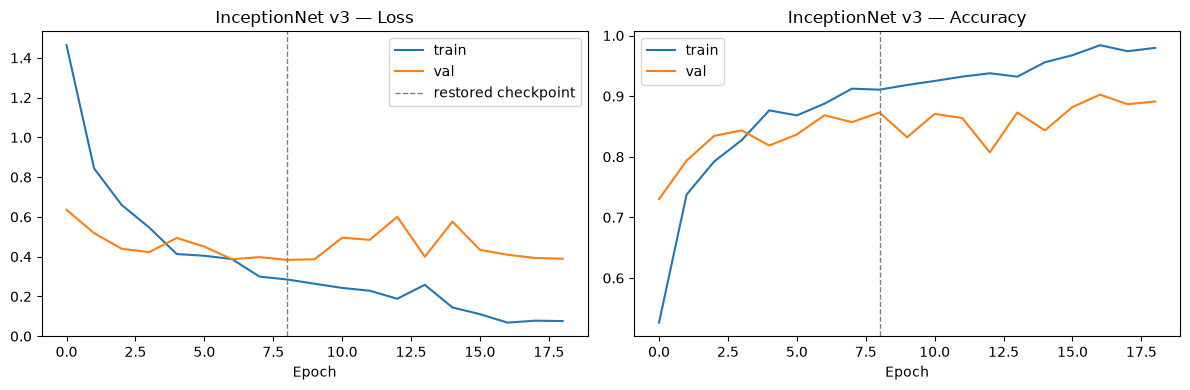

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.742


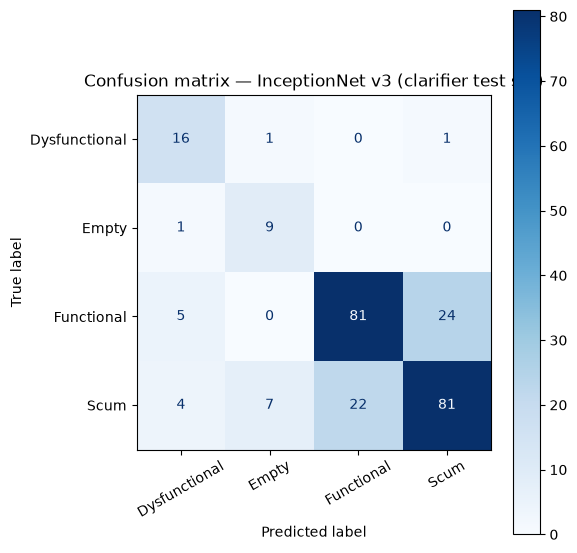

               precision    recall  f1-score   support

Dysfunctional      0.615     0.889     0.727        18
        Empty      0.529     0.900     0.667        10
   Functional      0.786     0.736     0.761       110
         Scum      0.764     0.711     0.736       114

     accuracy                          0.742       252
    macro avg      0.674     0.809     0.723       252
 weighted avg      0.754     0.742     0.744       252



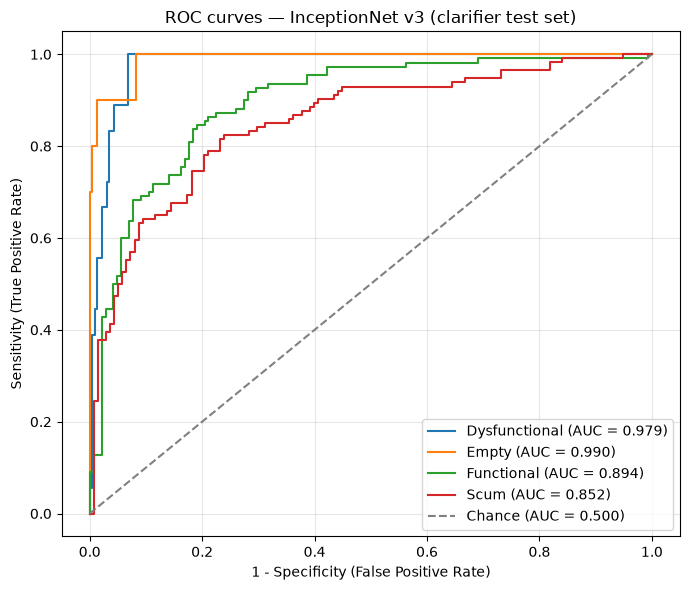

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.979
  Empty          : 0.990
  Functional     : 0.894
  Scum           : 0.852

Mean AUC (over 4/4 classes with test examples): 0.929


(np.float64(0.7420634920634921),
 {'Dysfunctional': 0.9788698955365622,
  'Empty': 0.9900826446280993,
  'Functional': 0.8944302176696544,
  'Scum': 0.8522120518688024})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/results_clarifier_inception_v3_Fisantekraal.pkl
Saved model weights to ../models/clarifier_inception_v3_cnn.pt
